# Backtest Markowitz — 58 ETFs sin filtrar (media semanal)

Igual que `01_backtest_markowitz.ipynb` pero:
- Usa `predicciones_arima_semanal.csv` (58 ETFs, sin filtrar por ARIMA)
- `etfs_comunes` = todos los 58 ETFs válidos por estacionalidad
- Retorno semanal = **media** de retornos logarítmicos diarios

Prueba las 3 configuraciones en un solo paso y rellena todas las hojas:

| Config | MAX_WEIGHT | RISK_AVERSION | Hoja detalle |
|--------|-----------|---------------|-------------|
| Base | 0.30 | 2.0 | `detalle_base` |
| Conservadora | 0.15 | 5.0 | `detalle_conservador` |
| Agresiva | 0.50 | 0.5 | `detalle_agresivo` |

El resumen de las 3 configs se acumula en `resumen_configs`.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from pypfopt import risk_models, EfficientFrontier
import gspread
from google.oauth2.service_account import Credentials

warnings.filterwarnings('ignore')

## Configuración

In [2]:
DATA_DIR             = '../Datos_csv'
SERVICE_ACCOUNT_FILE = '../3.Modelo_ML/Modelos_semanales/credenciales_google.json'
SHEET_URL            = 'https://docs.google.com/spreadsheets/d/1wT40LHZ_HYZq8ZXpTIeeK0LVaSPNdzBPJIHFR7HHIkk/edit?gid=0#gid=0'

SCOPES = [
    'https://www.googleapis.com/auth/spreadsheets',
    'https://www.googleapis.com/auth/drive',
]

FECHA_TRAIN_FIN = '2024-W29'
FECHA_TEST_INI  = '2024-W30'
FECHA_TEST_FIN  = '2026-W05'
CAPITAL_INICIAL = 100.0
MIN_WEEKS       = 52

# ── Las 3 configuraciones a probar ───────────────────────────────────────────
CONFIGURACIONES = [
    {'nombre': 'base',         'MAX_WEIGHT': 0.30, 'RISK_AVERSION': 2.0, 'hoja_detalle': 'detalle_base'},
    {'nombre': 'conservador',  'MAX_WEIGHT': 0.15, 'RISK_AVERSION': 5.0, 'hoja_detalle': 'detalle_conservador'},
    {'nombre': 'agresivo',     'MAX_WEIGHT': 0.50, 'RISK_AVERSION': 0.5, 'hoja_detalle': 'detalle_agresivo'},
]

HOJA_RESUMEN = 'resumen_configs'

## Carga de datos (una sola vez para todas las configuraciones)

In [3]:
adj_close = pd.read_csv(
    os.path.join(DATA_DIR, 'adj_close.csv'),
    index_col=0, parse_dates=True
)

with open(os.path.join(DATA_DIR, 'tickers_estacionalidad.json'), 'r', encoding='utf-8') as f:
    est_data = json.load(f)
tickers_filtrados = est_data['tickers_filtrados']

ret_log_diff = np.log(adj_close[tickers_filtrados]).diff().iloc[1:]

iso_cal  = ret_log_diff.index.isocalendar()
week_key = (
    iso_cal.year.astype(str) + '-W' + iso_cal.week.astype(str).str.zfill(2)
).values

# Retorno semanal = MEDIA de retornos logarítmicos diarios
ret_weekly_df = ret_log_diff.groupby(week_key).mean()
ret_weekly_df.index.name = 'week_key'

print(f'ETFs válidos: {len(tickers_filtrados)}')
print(f'Semanas: {len(ret_weekly_df)} | {ret_weekly_df.index[0]} -> {ret_weekly_df.index[-1]}')

ETFs válidos: 58
Semanas: 266 | 2021-W01 -> 2026-W06


In [4]:
# Predicciones ARIMA — 58 ETFs, sin filtrar
df_arima = pd.read_csv(
    os.path.join(DATA_DIR, 'predicciones_arima_semanal.csv'), encoding='utf-8-sig'
)
pred_arima_pivot = df_arima.pivot(
    index='Fecha_Semana', columns='Target', values='Prediccion'
)
pred_arima_pivot.index.name = 'week_key'

print(f'Predicciones ARIMA: {pred_arima_pivot.shape[1]} ETFs | '
      f'{pred_arima_pivot.index[0]} -> {pred_arima_pivot.index[-1]}')

# ETFs en cartera
etfs_comunes = [e for e in tickers_filtrados if e in ret_weekly_df.columns]
print(f'ETFs en cartera: {len(etfs_comunes)}')

# Semanas de backtest
semanas_test = [s for s in ret_weekly_df.index if FECHA_TEST_INI <= s <= FECHA_TEST_FIN]
print(f'Semanas de backtest: {len(semanas_test)-1} | {semanas_test[0]} -> {semanas_test[-1]}')

Predicciones ARIMA: 58 ETFs | 2024-W30 -> 2026-W06
ETFs en cartera: 58
Semanas de backtest: 79 | 2024-W30 -> 2026-W05


## Funciones del optimizador

In [5]:
def calcular_covarianza_lw(ret_hist):
    Sigma = risk_models.CovarianceShrinkage(
        ret_hist, returns_data=True, frequency=1
    ).ledoit_wolf()
    return risk_models.fix_nonpositive_semidefinite(Sigma)


def optimizar_markowitz(mu, cov, etfs, max_weight, risk_aversion):
    n = len(etfs)
    mu_series = pd.Series(mu, index=etfs)
    solvers = set(cp.installed_solvers())
    if 'OSQP' in solvers:
        solver, solver_opts = 'OSQP', {'max_iter': 300000}
    else:
        solver, solver_opts = 'SCS', {'max_iters': 100000}
    try:
        ef = EfficientFrontier(
            mu_series, cov,
            weight_bounds=(0, max_weight),
            solver=solver, solver_options=solver_opts
        )
        ef.max_quadratic_utility(risk_aversion=2 * risk_aversion)
        return dict(ef.clean_weights())
    except Exception as e:
        print(f'  [FALLBACK equal-weight] {e}')
        return {etf: 1.0 / n for etf in etfs}


def retorno_cartera(pesos, ret_real):
    ret_simple = np.exp(ret_real) - 1
    return sum(pesos.get(e, 0.0) * ret_simple.get(e, 0.0) for e in pesos)

## Backtest — bucle sobre las 3 configuraciones

In [6]:
resultados_configs = {}   # guarda dfs y resumen de cada config

for cfg in CONFIGURACIONES:
    MAX_WEIGHT    = cfg['MAX_WEIGHT']
    RISK_AVERSION = cfg['RISK_AVERSION']
    nombre_cfg    = cfg['nombre']

    print(f"\n{'='*60}")
    print(f"  Config: {nombre_cfg.upper()} | MAX_WEIGHT={MAX_WEIGHT} | RISK_AVERSION={RISK_AVERSION}")
    print(f"{'='*60}")

    registros    = {k: [] for k in ['media_historica', 'ultimo_valor', 'arima']}
    capital      = {k: CAPITAL_INICIAL for k in registros}
    capital_pico = {k: CAPITAL_INICIAL for k in registros}

    for i, semana_decision in enumerate(semanas_test[:-1]):
        semana_inversion = semanas_test[i + 1]

        hist = ret_weekly_df.loc[
            ret_weekly_df.index <= semana_decision, etfs_comunes
        ].dropna(how='all')

        if len(hist) < MIN_WEEKS:
            continue

        try:
            cov = calcular_covarianza_lw(hist[etfs_comunes].dropna())
        except Exception as e:
            print(f'[{semana_decision}] Error covarianza: {e}')
            continue

        if semana_inversion not in ret_weekly_df.index:
            continue
        ret_real = ret_weekly_df.loc[semana_inversion, etfs_comunes]

        mu_media  = hist[etfs_comunes].mean().values
        mu_ultimo = hist[etfs_comunes].iloc[-1].values
        mu_arima  = (
            pred_arima_pivot.loc[semana_inversion, etfs_comunes].values
            if semana_inversion in pred_arima_pivot.index
            else mu_media
        )

        estrategias = [
            ('media_historica', optimizar_markowitz(mu_media,  cov, etfs_comunes, MAX_WEIGHT, RISK_AVERSION), mu_media),
            ('ultimo_valor',    optimizar_markowitz(mu_ultimo, cov, etfs_comunes, MAX_WEIGHT, RISK_AVERSION), mu_ultimo),
            ('arima',           optimizar_markowitz(mu_arima,  cov, etfs_comunes, MAX_WEIGHT, RISK_AVERSION), mu_arima),
        ]

        for nombre, pesos, mu_used in estrategias:
            ret_cart = retorno_cartera(pesos, ret_real)
            cap_ini  = capital[nombre]
            cap_fin  = cap_ini * (1.0 + ret_cart)
            capital[nombre] = cap_fin

            capital_pico[nombre] = max(capital_pico[nombre], cap_fin)
            drawdown  = (cap_fin - capital_pico[nombre]) / capital_pico[nombre]
            rent_acum = (cap_fin - CAPITAL_INICIAL) / CAPITAL_INICIAL

            row = {
                'Config':                nombre_cfg,
                'MAX_WEIGHT':            MAX_WEIGHT,
                'RISK_AVERSION':         RISK_AVERSION,
                'FechaDecision':         semana_decision,
                'FechaInversion':        semana_inversion,
                'Estrategia':            nombre,
                'CapitalInicio':         round(cap_ini, 4),
                'RetornoCarteraReal':    round(ret_cart, 6),
                'CapitalFinal':          round(cap_fin, 4),
                'RentabilidadAcumulada': round(rent_acum, 6),
                'Drawdown':              round(drawdown, 6),
                'SumaPesos':             round(sum(pesos.values()), 6),
                'Estado':                'DONE',
            }
            for etf in etfs_comunes:
                row[f'{etf}_peso']    = round(pesos.get(etf, 0.0), 6)
            for j, etf in enumerate(etfs_comunes):
                row[f'{etf}_rentexp'] = round(float(mu_used[j]), 6)
            for etf in etfs_comunes:
                val = ret_real.get(etf, np.nan)
                row[f'{etf}_real'] = round(float(val), 6) if not np.isnan(val) else None

            registros[nombre].append(row)

        if (i + 1) % 20 == 0:
            print(f'  Semana {i+1:3d}/{len(semanas_test)-1}: {semana_decision} -> {semana_inversion}')
            for k in capital:
                print(f'    {k}: {capital[k]:.2f}')

    # Métricas de esta configuración
    nombres_bt = {
        'media_historica': 'Markowitz_media_historica',
        'ultimo_valor':    'Markowitz_ultimo_valor',
        'arima':           'Markowitz_ARIMA_sin_filtrar',
    }
    ids_bt = {
        'media_historica': f'{nombre_cfg}_MH',
        'ultimo_valor':    f'{nombre_cfg}_UV',
        'arima':           f'{nombre_cfg}_AR',
    }

    dfs = {k: pd.DataFrame(v) for k, v in registros.items()}

    resumen_rows = []
    for nombre, df_e in dfs.items():
        if df_e.empty:
            continue
        rets  = df_e['RetornoCarteraReal'].values
        cap_f = df_e['CapitalFinal'].iloc[-1]
        vol   = np.std(rets, ddof=1) * np.sqrt(52)
        sharpe = (np.mean(rets) * 52) / (vol + 1e-10)
        caps = df_e['CapitalFinal'].values
        peak, max_dd = caps[0], 0.0
        for c in caps:
            peak = max(peak, c)
            max_dd = min(max_dd, (c - peak) / peak)
        resumen_rows.append({
            'ID':                    ids_bt[nombre],
            'Config':                nombre_cfg,
            'MAX_WEIGHT':            MAX_WEIGHT,
            'RISK_AVERSION':         RISK_AVERSION,
            'Estrategia':            nombres_bt[nombre],
            'ETFs_universo':         len(etfs_comunes),
            'Agregacion_semanal':    'media',
            'FechaTrainIni':         '2021-W01',
            'FechaTrainFin':         FECHA_TRAIN_FIN,
            'FechaTestIni':          FECHA_TEST_INI,
            'FechaTestFin':          df_e['FechaInversion'].iloc[-1],
            'CapitalInicial':        CAPITAL_INICIAL,
            'CapitalFinal':          round(cap_f, 4),
            'RentabilidadAcumulada': f'{(cap_f-CAPITAL_INICIAL)/CAPITAL_INICIAL*100:.2f}%',
            'Volatilidad':           f'{vol*100:.2f}%',
            'Sharpe':                round(sharpe, 4),
            'MaxDrawdown':           f'{max_dd*100:.2f}%',
            'SemanasPositivas':      int((rets > 0).sum()),
            'Estado':                'DONE',
        })

    df_resumen = pd.DataFrame(resumen_rows)
    print(f"\n  Resultados {nombre_cfg.upper()}:")
    print(df_resumen[['Estrategia','CapitalFinal','RentabilidadAcumulada',
                       'Volatilidad','Sharpe','MaxDrawdown']].to_string(index=False))

    resultados_configs[nombre_cfg] = {
        'cfg':        cfg,
        'dfs':        dfs,
        'df_resumen': df_resumen,
        'ids_bt':     ids_bt,
        'nombres_bt': nombres_bt,
    }

print("\n\n=== TODAS LAS CONFIGURACIONES COMPLETADAS ===")


  Config: BASE | MAX_WEIGHT=0.3 | RISK_AVERSION=2.0
  Semana  20/79: 2024-W49 -> 2024-W50
    media_historica: 99.82
    ultimo_valor: 102.49
    arima: 99.98
  Semana  40/79: 2025-W17 -> 2025-W18
    media_historica: 97.89
    ultimo_valor: 101.38
    arima: 99.04
  Semana  60/79: 2025-W37 -> 2025-W38
    media_historica: 100.68
    ultimo_valor: 100.96
    arima: 102.74

  Resultados BASE:
                 Estrategia  CapitalFinal RentabilidadAcumulada Volatilidad  Sharpe MaxDrawdown
  Markowitz_media_historica      104.1227                 4.12%       4.42%  0.6232      -3.71%
     Markowitz_ultimo_valor      103.3822                 3.38%       4.24%  0.5379      -4.90%
Markowitz_ARIMA_sin_filtrar      102.2960                 2.30%       3.53%  0.4402      -4.19%

  Config: CONSERVADOR | MAX_WEIGHT=0.15 | RISK_AVERSION=5.0
  Semana  20/79: 2024-W49 -> 2024-W50
    media_historica: 100.51
    ultimo_valor: 100.67
    arima: 100.84
  Semana  40/79: 2025-W17 -> 2025-W18
    media_hi

## Gráficos comparativos

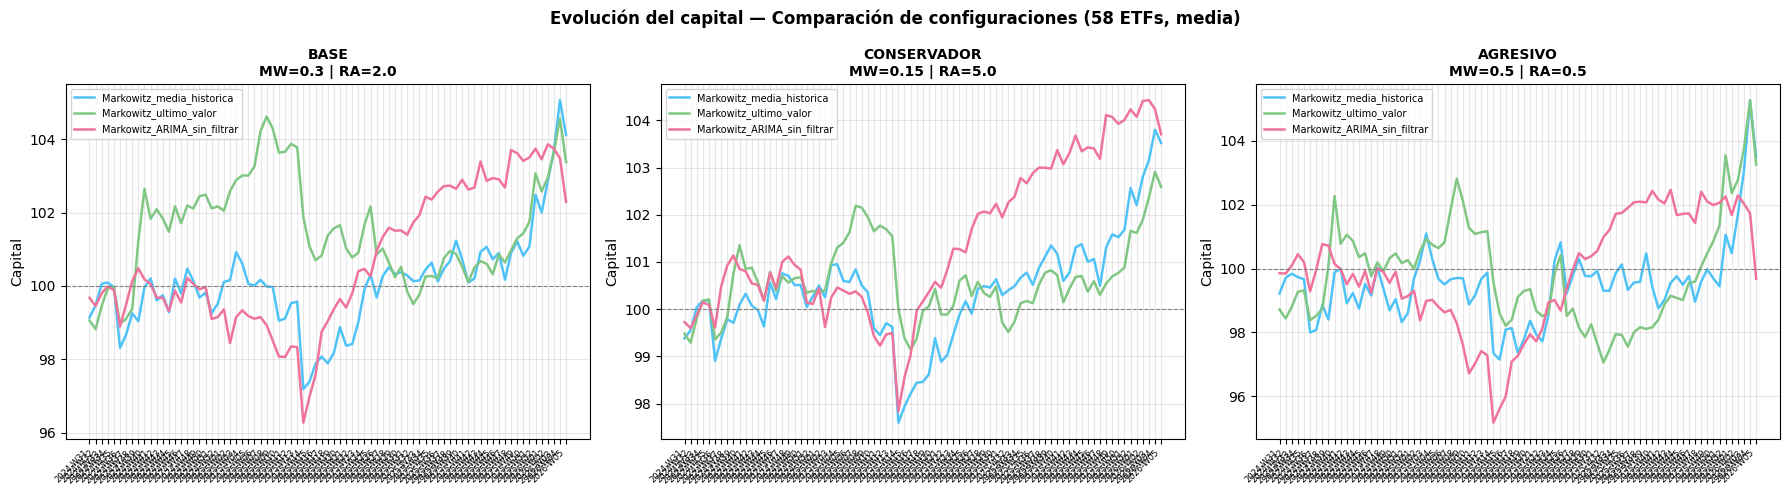

Gráfico guardado: comparacion_configs_sin_filtrar.png


In [7]:
colores = {
    'media_historica': '#4FC3F7',
    'ultimo_valor':    '#81C784',
    'arima':           '#EF739A',
}
lineas = {'base': '-', 'conservador': '--', 'agresivo': ':'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, cfg in zip(axes, CONFIGURACIONES):
    nombre_cfg = cfg['nombre']
    res = resultados_configs[nombre_cfg]
    for nombre, df_e in res['dfs'].items():
        if not df_e.empty:
            ax.plot(df_e['FechaInversion'], df_e['CapitalFinal'],
                    label=res['nombres_bt'][nombre], color=colores[nombre], linewidth=1.8)
    ax.axhline(CAPITAL_INICIAL, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f"{nombre_cfg.upper()}\nMW={cfg['MAX_WEIGHT']} | RA={cfg['RISK_AVERSION']}",
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Capital')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)

plt.suptitle('Evolución del capital — Comparación de configuraciones (58 ETFs, media)', 
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('comparacion_configs_sin_filtrar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparacion_configs_sin_filtrar.png')

## Escritura en Google Sheets

In [10]:
creds       = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
client      = gspread.authorize(creds)
spreadsheet = client.open_by_url(SHEET_URL)

hojas_disponibles = [ws.title for ws in spreadsheet.worksheets()]
print('Conectado a:', spreadsheet.title)
print('Hojas disponibles:')
for h in hojas_disponibles:
    print(f'  → "{h}"')

Conectado a: Markowitz sin filtrar
Hojas disponibles:
  → "resumen_configs"
  → "detalle_base"
  → "detalle_conservador"
  → "detalle_agresivo"


In [11]:
# ── Hoja resumen_configs ──────────────────────────────────────────────────────
ws_resumen = spreadsheet.worksheet(HOJA_RESUMEN)
ws_resumen.clear()

todas_filas_resumen = [res['df_resumen'] for res in resultados_configs.values()]
df_resumen_total = pd.concat(todas_filas_resumen, ignore_index=True)

ws_resumen.append_row(list(df_resumen_total.columns), value_input_option='RAW')
for _, row in df_resumen_total.iterrows():
    ws_resumen.append_row(
        [v if isinstance(v, (int, float)) else str(v) for v in row.tolist()],
        value_input_option='RAW'
    )
print(f'Hoja "{HOJA_RESUMEN}": {len(df_resumen_total)} filas escritas (3 configs × 3 estrategias)')

Hoja "resumen_configs": 9 filas escritas (3 configs × 3 estrategias)


In [12]:
# ── Hoja detalle por config ───────────────────────────────────────────────────
cols_base = [
    'ID_Backtest', 'Config', 'MAX_WEIGHT', 'RISK_AVERSION',
    'FechaDecision', 'FechaInversion', 'Estrategia',
    'CapitalInicio', 'RetornoCarteraReal', 'CapitalFinal',
    'RentabilidadAcumulada', 'Drawdown', 'SumaPesos', 'Estado',
]
cols_pesos   = [f'{e}_peso'    for e in etfs_comunes]
cols_rentexp = [f'{e}_rentexp' for e in etfs_comunes]
cols_real    = [f'{e}_real'    for e in etfs_comunes]
all_cols = cols_base + cols_pesos + cols_rentexp + cols_real

for nombre_cfg, res in resultados_configs.items():
    hoja_det = res['cfg']['hoja_detalle']
    ws_det   = spreadsheet.worksheet(hoja_det)
    ws_det.clear()
    ws_det.append_row(all_cols, value_input_option='RAW')

    rows_batch = []
    for nombre, df_e in res['dfs'].items():
        for _, row in df_e.iterrows():
            fila = [res['ids_bt'][nombre]]
            for col in cols_base[1:]:
                val = row.get(col, '')
                fila.append('' if (isinstance(val, float) and np.isnan(val)) else val)
            for col in cols_pesos + cols_rentexp + cols_real:
                val = row.get(col, '')
                fila.append('' if (val is None or (isinstance(val, float) and np.isnan(val))) else val)
            rows_batch.append(fila)

    batch_size = 500
    for i in range(0, len(rows_batch), batch_size):
        ws_det.append_rows(rows_batch[i:i+batch_size], value_input_option='RAW')

    print(f'Hoja "{hoja_det}": {len(rows_batch)} filas escritas')

Hoja "detalle_base": 237 filas escritas
Hoja "detalle_conservador": 237 filas escritas
Hoja "detalle_agresivo": 237 filas escritas


In [13]:
print('\n=== RESUMEN COMPARATIVO FINAL ===')
print(f'{"Config":<14} {"Estrategia":<30} {"Capital":>8} {"Rent":>8} {"Sharpe":>7} {"MaxDD":>9}')
print('-' * 80)
for nombre_cfg, res in resultados_configs.items():
    for _, row in res['df_resumen'].iterrows():
        print(f"{nombre_cfg:<14} {row['Estrategia']:<30} "
              f"{row['CapitalFinal']:>8.2f} {row['RentabilidadAcumulada']:>8} "
              f"{row['Sharpe']:>7.4f} {row['MaxDrawdown']:>9}")


=== RESUMEN COMPARATIVO FINAL ===
Config         Estrategia                      Capital     Rent  Sharpe     MaxDD
--------------------------------------------------------------------------------
base           Markowitz_media_historica        104.12    4.12%  0.6232    -3.71%
base           Markowitz_ultimo_valor           103.38    3.38%  0.5379    -4.90%
base           Markowitz_ARIMA_sin_filtrar      102.30    2.30%  0.4402    -4.19%
conservador    Markowitz_media_historica        103.52    3.52%  0.7053    -3.33%
conservador    Markowitz_ultimo_valor           102.59    2.59%  0.5999    -2.98%
conservador    Markowitz_ARIMA_sin_filtrar      103.70    3.70%  0.8559    -3.26%
agresivo       Markowitz_media_historica        103.50    3.50%  0.4165    -3.91%
agresivo       Markowitz_ultimo_valor           103.26    3.26%  0.4179    -5.60%
agresivo       Markowitz_ARIMA_sin_filtrar       99.68   -0.32% -0.0313    -5.55%
